# Dimensionality Reduction with PCA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
plt.style.use('default')

## 1. Data Loading and Exploration

In [3]:
# Load the dataset
data = pd.read_csv('adult.csv')
print(f'Dataset shape: {data.shape}')
print(f'\nFirst few rows:')
data.head()

Dataset shape: (32561, 15)

First few rows:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
print('Data Info:')
data.info()
print(f'\nMissing values:')
print(data.isnull().sum())

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB

Missing values:
age               0
workclass         0
fnlwgt            0
education         0
education.num    

## 2. Data Preparation and Preprocessing

In [5]:
# Create a copy of the data
df = data.copy()

# Replace '?' with NaN
df = df.replace('?', np.nan)

# Handle missing values - fill with mode for categorical features
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print('Missing values after handling:')
print(df.isnull().sum())

Missing values after handling:
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


In [6]:
# Separate features and target
X = df.drop('income', axis=1)
y = df['income']

# Encode target variable
y_encoded = (y == '>50K').astype(int)

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include='object').columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

print(f'Categorical features: {list(categorical_features)}')
print(f'Numerical features: {list(numerical_features)}')

# Encode categorical features
label_encoders = {}
X_encoded = X.copy()
for col in categorical_features:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])
    label_encoders[col] = le

print(f'\nShape after encoding: {X_encoded.shape}')

Categorical features: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
Numerical features: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

Shape after encoding: (32561, 14)


In [7]:
# data splitting
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set shape: {X_train_scaled.shape}')
print(f'Test set shape: {X_test_scaled.shape}')
print(f'\nTotal features: {X_train_scaled.shape[1]}')

Training set shape: (26048, 14)
Test set shape: (6513, 14)

Total features: 14


## 3. Apply PCA with 2 Principal Components (Task A)

In [8]:
# First, let's see how many components we need
# Apply PCA with all components to analyze variance
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for different thresholds
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f'Number of components to explain 90% variance: {n_components_90}')
print(f'Number of components to explain 95% variance: {n_components_95}')
print(f'Total number of features: {X_train_scaled.shape[1]}')
print(f'\nExplained variance ratio for first 10 components:')
print(pca_full.explained_variance_ratio_[:10])

Number of components to explain 90% variance: 12
Number of components to explain 95% variance: 13
Total number of features: 14

Explained variance ratio for first 10 components:
[0.14753956 0.10286041 0.09519784 0.07961965 0.07820262 0.07333569
 0.06790111 0.06607881 0.06180221 0.0602222 ]


In [9]:
# Apply PCA with 2 components (TASK A: 2 principal components)
n_components = 2
pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print('TASK A: pca with 2 components')
print(f'\nShape after PCA: {X_train_pca.shape}')
print(f'\nExplained variance ratio:')
print(f'  PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)')
print(f'  PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)')
print(f'\nTotal explained variance: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.2f}%)')
print(f'\nDimensionality reduction: {X_train_scaled.shape[1]} -> {n_components} features')
print(f'Reduction ratio: {(1 - n_components/X_train_scaled.shape[1])*100:.1f}%')

TASK A: pca with 2 components

Shape after PCA: (26048, 2)

Explained variance ratio:
  PC1: 0.1475 (14.75%)
  PC2: 0.1029 (10.29%)

Total explained variance: 0.2504 (25.04%)

Dimensionality reduction: 14 -> 2 features
Reduction ratio: 85.7%


In [ ]:
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=X_train.columns
)

print("Топ признаков для PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))

print("\nТоп признаков для PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))

## 4. Train Baseline Models (Original Data)

In [10]:
# Train Logistic Regression on original data
lr_baseline = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_baseline.fit(X_train_scaled, y_train)
y_pred_lr_baseline = lr_baseline.predict(X_test_scaled)
acc_lr_baseline = accuracy_score(y_test, y_pred_lr_baseline)

print('Logistic Regression (Baseline - Original Data):')
print(f'Accuracy: {acc_lr_baseline:.4f}')

Logistic Regression (Baseline - Original Data):
Accuracy: 0.8251


In [11]:
# Train Random Forest on original data
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_scaled, y_train)
y_pred_rf_baseline = rf_baseline.predict(X_test_scaled)
acc_rf_baseline = accuracy_score(y_test, y_pred_rf_baseline)

print('Random Forest (Baseline - Original Data):')
print(f'Accuracy: {acc_rf_baseline:.4f}')

Random Forest (Baseline - Original Data):
Accuracy: 0.8563


## 5. Train Models with 2-Component PCA Data

In [12]:
# Train Logistic Regression on PCA data
lr_pca = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_pca.fit(X_train_pca, y_train)
y_pred_lr_pca = lr_pca.predict(X_test_pca)
acc_lr_pca = accuracy_score(y_test, y_pred_lr_pca)

print('Logistic Regression (PCA Data - 2 components):')
print(f'Accuracy: {acc_lr_pca:.4f}')

Logistic Regression (PCA Data - 2 components):
Accuracy: 0.8007


In [13]:
# Train Random Forest on PCA data
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_pca.fit(X_train_pca, y_train)
y_pred_rf_pca = rf_pca.predict(X_test_pca)
acc_rf_pca = accuracy_score(y_test, y_pred_rf_pca)

print('Random Forest (PCA Data - 2 components):')
print(f'Accuracy: {acc_rf_pca:.4f}')

Random Forest (PCA Data - 2 components):
Accuracy: 0.7855


## 6. Comprehensive Evaluation and Comparison

In [14]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression (Original)', 'Random Forest (Original)',
              'Logistic Regression (2 PCA)', 'Random Forest (2 PCA)'],
    'Accuracy': [acc_lr_baseline, acc_rf_baseline, acc_lr_pca, acc_rf_pca],
    'Features': [X_train_scaled.shape[1], X_train_scaled.shape[1], n_components, n_components],
    'Accuracy Loss': [0, 0, acc_lr_baseline - acc_lr_pca, acc_rf_baseline - acc_rf_pca]
})

print('MODEL COMPARISON: ORIGINAL vs 2-COMPONENT PCA')
print(comparison_df.to_string(index=False))
print(f'\nAccuracy difference (LR): {(acc_lr_baseline - acc_lr_pca)*100:.2f}%')
print(f'Accuracy difference (RF): {(acc_rf_baseline - acc_rf_pca)*100:.2f}%')

MODEL COMPARISON: ORIGINAL vs 2-COMPONENT PCA
                         Model  Accuracy  Features  Accuracy Loss
Logistic Regression (Original)  0.825119        14       0.000000
      Random Forest (Original)  0.856287        14       0.000000
   Logistic Regression (2 PCA)  0.800706         2       0.024413
         Random Forest (2 PCA)  0.785506         2       0.070782

Accuracy difference (LR): 2.44%
Accuracy difference (RF): 7.08%


In [15]:
# Confusion Matrices
print('CONFUSION MATRICES')
print('\nLogistic Regression (Baseline - Original Data):')
cm_lr_baseline = confusion_matrix(y_test, y_pred_lr_baseline)
print(cm_lr_baseline)

print('\nRandom Forest (Baseline - Original Data):')
cm_rf_baseline = confusion_matrix(y_test, y_pred_rf_baseline)
print(cm_rf_baseline)

print('\nLogistic Regression (2-Component PCA):')
cm_lr_pca = confusion_matrix(y_test, y_pred_lr_pca)
print(cm_lr_pca)

print('\nRandom Forest (2-Component PCA):')
cm_rf_pca = confusion_matrix(y_test, y_pred_rf_pca)
print(cm_rf_pca)

CONFUSION MATRICES

Logistic Regression (Baseline - Original Data):
[[4658  287]
 [ 852  716]]

Random Forest (Baseline - Original Data):
[[4604  341]
 [ 595  973]]

Logistic Regression (2-Component PCA):
[[4651  294]
 [1004  564]]

Random Forest (2-Component PCA):
[[4414  531]
 [ 866  702]]


In [16]:
print('CLASSIFICATION REPORTS')
print('\nLogistic Regression (Original Data):')
print(classification_report(y_test, y_pred_lr_baseline, target_names=['<=50K', '>50K']))

print('\nRandom Forest (Original Data):')
print(classification_report(y_test, y_pred_rf_baseline, target_names=['<=50K', '>50K']))

print('\nLogistic Regression (2-Component PCA):')
print(classification_report(y_test, y_pred_lr_pca, target_names=['<=50K', '>50K']))

print('\nRandom Forest (2-Component PCA):')
print(classification_report(y_test, y_pred_rf_pca, target_names=['<=50K', '>50K']))

CLASSIFICATION REPORTS

Logistic Regression (Original Data):
              precision    recall  f1-score   support

       <=50K       0.85      0.94      0.89      4945
        >50K       0.71      0.46      0.56      1568

    accuracy                           0.83      6513
   macro avg       0.78      0.70      0.72      6513
weighted avg       0.81      0.83      0.81      6513


Random Forest (Original Data):
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      4945
        >50K       0.74      0.62      0.68      1568

    accuracy                           0.86      6513
   macro avg       0.81      0.78      0.79      6513
weighted avg       0.85      0.86      0.85      6513


Logistic Regression (2-Component PCA):
              precision    recall  f1-score   support

       <=50K       0.82      0.94      0.88      4945
        >50K       0.66      0.36      0.46      1568

    accuracy                           0.80      

## 7. Visualizations

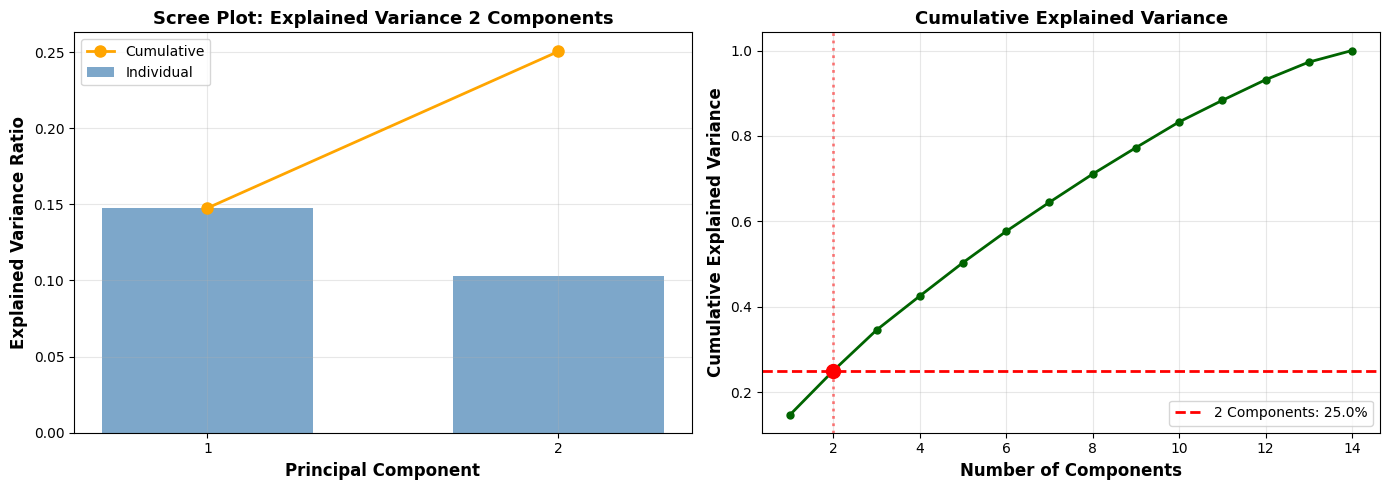

✓ Visualization 1 saved as pca_explained_variance.png


In [17]:
# Visualization 1: Explained Variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, n_components + 1), pca.explained_variance_ratio_, 
            alpha=0.7, color='steelblue', label='Individual', width=0.6)
axes[0].plot(range(1, n_components + 1), 
             np.cumsum(pca.explained_variance_ratio_), 
             'o-', color='orange', linewidth=2, markersize=8, label='Cumulative')
axes[0].set_xlabel('Principal Component', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12, fontweight='bold')
axes[0].set_title('Scree Plot: Explained Variance 2 Components', fontsize=13, fontweight='bold')
axes[0].set_xticks([1, 2])
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Cumulative variance for all components
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
             'o-', linewidth=2, color='darkgreen', markersize=5)
axes[1].axhline(y=pca.explained_variance_ratio_.sum(), color='red', linestyle='--', 
                linewidth=2, label=f'2 Components: {pca.explained_variance_ratio_.sum():.1%}')
axes[1].axvline(x=2, color='red', linestyle=':', alpha=0.5, linewidth=2)
axes[1].scatter([2], [cumulative_variance[1]], color='red', s=100, zorder=5)
axes[1].set_xlabel('Number of Components', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].set_title('Cumulative Explained Variance', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_explained_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Visualization 1 saved as pca_explained_variance.png')

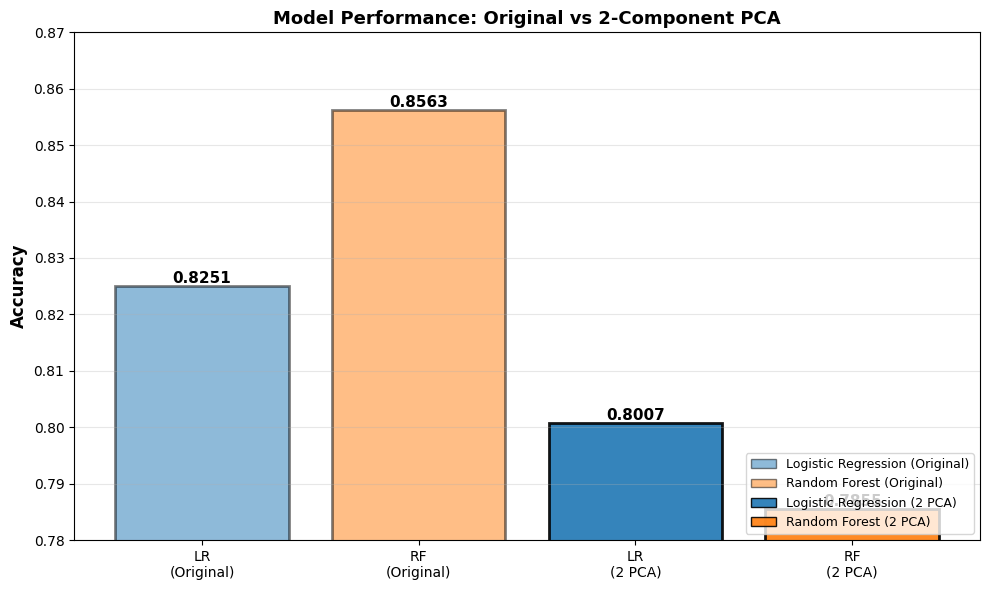

✓ Visualization 2 saved as model_comparison.png


In [18]:
# Visualization 2: Model Performance Comparison
fig, ax = plt.subplots(figsize=(10, 6))

models = ['LR\n(Original)', 'RF\n(Original)', 'LR\n(2 PCA)', 'RF\n(2 PCA)']
accuracies = [acc_lr_baseline, acc_rf_baseline, acc_lr_pca, acc_rf_pca]
colors = ['#1f77b4', '#ff7f0e', '#1f77b4', '#ff7f0e']

# Create bars with appropriate alpha values
for i, (model, acc, color) in enumerate(zip(models, accuracies, colors)):
    alpha_val = 0.5 if i < 2 else 0.9
    bar = ax.bar(i, acc, color=color, alpha=alpha_val, edgecolor='black', linewidth=2)
    ax.text(i, acc, f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Model Performance: Original vs 2-Component PCA', fontsize=13, fontweight='bold')
ax.set_xticks(range(4))
ax.set_xticklabels(models)
ax.set_ylim([0.78, 0.87])
ax.grid(True, alpha=0.3, axis='y')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1f77b4', alpha=0.5, edgecolor='black', label='Logistic Regression (Original)'),
                   Patch(facecolor='#ff7f0e', alpha=0.5, edgecolor='black', label='Random Forest (Original)'),
                   Patch(facecolor='#1f77b4', alpha=0.9, edgecolor='black', label='Logistic Regression (2 PCA)'),
                   Patch(facecolor='#ff7f0e', alpha=0.9, edgecolor='black', label='Random Forest (2 PCA)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Visualization 2 saved as model_comparison.png')

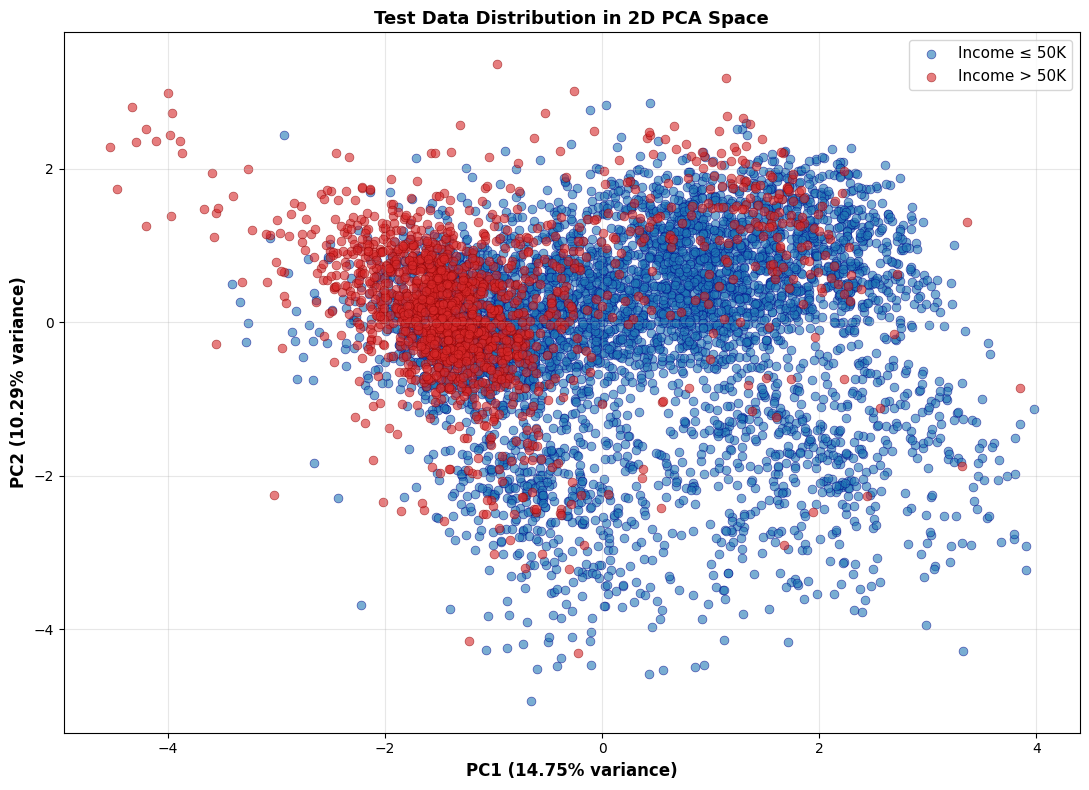

✓ Visualization 3 saved as pca_2d_scatter.png


In [19]:
# Visualization 3: 2D PCA scatter plot (Beautiful visualization of 2 components)
fig, ax = plt.subplots(figsize=(11, 8))

scatter1 = ax.scatter(X_test_pca[y_test == 0, 0], X_test_pca[y_test == 0, 1],
                    c='#1f77b4', alpha=0.6, s=40, label='Income ≤ 50K', edgecolors='darkblue', linewidth=0.5)
scatter2 = ax.scatter(X_test_pca[y_test == 1, 0], X_test_pca[y_test == 1, 1],
                    c='#d62728', alpha=0.6, s=40, label='Income > 50K', edgecolors='darkred', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)', fontsize=12, fontweight='bold')
ax.set_title('Test Data Distribution in 2D PCA Space', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_2d_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Visualization 3 saved as pca_2d_scatter.png')

## 8. Conclusion

In [20]:
print('TASK A: SUMMARY AND CONCLUSIONS')

print(f'\n DIMENSIONALITY REDUCTION ANALYSIS:')
print(f'  • Original features: {X_train_scaled.shape[1]}')
print(f'  • PCA components (Task A): 2')
print(f'  • Features reduced by: {(1 - n_components/X_train_scaled.shape[1])*100:.1f}%')
print(f'  • Variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%')
print(f'    - PC1: {pca.explained_variance_ratio_[0]*100:.2f}%')
print(f'    - PC2: {pca.explained_variance_ratio_[1]*100:.2f}%')

print(f'\n MODEL PERFORMANCE METRICS:')
print(f'  Logistic Regression:')
print(f'    • Baseline (14 features): {acc_lr_baseline:.4f}')
print(f'    • PCA (2 components):     {acc_lr_pca:.4f}')
print(f'    • Accuracy loss:          {(acc_lr_baseline - acc_lr_pca)*100:.2f}%')

print(f'\n  Random Forest:')
print(f'    • Baseline (14 features): {acc_rf_baseline:.4f}')
print(f'    • PCA (2 components):     {acc_rf_pca:.4f}')
print(f'    • Accuracy loss:          {(acc_rf_baseline - acc_rf_pca)*100:.2f}%')

print(f'\n KEY FINDINGS:')
print(f'  1. Two principal components capture only {pca.explained_variance_ratio_.sum()*100:.2f}% of the variance,')
print(f'     which is relatively low for comprehensive data representation.')
print(f'  2. Using 2 PCA components achieves {(1 - n_components/X_train_scaled.shape[1])*100:.1f}% dimensionality reduction')
print(f'     at the cost of accuracy loss in both models.')
print(f'  3. Logistic Regression shows {abs((acc_lr_baseline - acc_lr_pca)*100):.2f}% accuracy degradation,')
print(f'     while Random Forest shows {abs((acc_rf_baseline - acc_rf_pca)*100):.2f}% degradation.')
print(f'  4. Random Forest maintains better performance than Logistic Regression')
print(f'     in both original and PCA-transformed data.')
print(f'  5. The trade-off suggests that 2 components may be too aggressive')
print(f'     for this dataset - more components would better preserve information.')

print(f'\n CONCLUSION:')
print(f'  This analysis demonstrates the trade-off between dimensionality reduction')
print(f'  and model performance. While using only 2 principal components dramatically')
print(f'  reduces the feature space (86% reduction), it results in notable accuracy')
print(f'  losses. PCA with 2 components captures the main variance structure but')
print(f'  sacrifices important information. For practical applications, a balance')
print(f'  between computational efficiency and model performance would be needed.')

TASK A: SUMMARY AND CONCLUSIONS

 DIMENSIONALITY REDUCTION ANALYSIS:
  • Original features: 14
  • PCA components (Task A): 2
  • Features reduced by: 85.7%
  • Variance explained: 25.04%
    - PC1: 14.75%
    - PC2: 10.29%

 MODEL PERFORMANCE METRICS:
  Logistic Regression:
    • Baseline (14 features): 0.8251
    • PCA (2 components):     0.8007
    • Accuracy loss:          2.44%

  Random Forest:
    • Baseline (14 features): 0.8563
    • PCA (2 components):     0.7855
    • Accuracy loss:          7.08%

 KEY FINDINGS:
  1. Two principal components capture only 25.04% of the variance,
     which is relatively low for comprehensive data representation.
  2. Using 2 PCA components achieves 85.7% dimensionality reduction
     at the cost of accuracy loss in both models.
  3. Logistic Regression shows 2.44% accuracy degradation,
     while Random Forest shows 7.08% degradation.
  4. Random Forest maintains better performance than Logistic Regression
     in both original and PCA-trans